# Chapter 3 Practical 07: Graph-Based and Explainable Collaborative Filtering

Learning objectives:
- Build a bipartite user-item graph.
- Run Personalized PageRank from a target user.
- Recommend unseen items from graph scores.
- Explain recommendations using paths and neighbor evidence.
- Add a simple hybrid fallback for cold start.

Slide connection: bipartite graphs, Personalized PageRank, graph-based CF benefits, explainable CF, and cold-start fallback.


In [1]:
# Teaching note: Load ratings and movies with a Colab-safe fallback. Local files are used first; GitHub raw CSVs are used when opened directly from GitHub.
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIRS = [
    Path("data"),
    Path("../data"),
    Path("chapter_03_collaborative_filtering/data"),
]
GITHUB_DATA_URL = "https://raw.githubusercontent.com/MehrdadJalali-AI/RecommenderSystems/main/chapter_03_collaborative_filtering/data"

def read_chapter3_csv(filename):
    for data_dir in DATA_DIRS:
        csv_path = data_dir / filename
        if csv_path.exists():
            print(f"Loaded {filename} from {csv_path}")
            return pd.read_csv(csv_path)
    url = f"{GITHUB_DATA_URL}/{filename}"
    print(f"Local file not found. Loading {filename} from GitHub raw URL.")
    return pd.read_csv(url)

ratings = read_chapter3_csv("ratings_chapter3.csv")
movies = read_chapter3_csv("movies_chapter3.csv")
ratings_named = ratings.merge(movies, on="movie_id", how="left")
# Pivot interactions into rows = users and columns = items.
rating_matrix = ratings_named.pivot_table(index="user_id", columns="title", values="rating")
rating_matrix


Loaded ratings_chapter3.csv from data/ratings_chapter3.csv
Loaded movies_chapter3.csv from data/movies_chapter3.csv


title,Blade Runner,Finding Nemo,Independence Day,Jurassic Park,Star Wars,Terminator 2,The Matrix,The Notebook,Titanic,Toy Story
user_id,,,,,,,,,,
Alice,5.0,NaN,4.0,NaN,4.0,NaN,5.0,NaN,NaN,NaN
Bob,NaN,NaN,6.0,4.0,7.0,4.0,7.0,NaN,NaN,NaN
Chris,NaN,NaN,2.0,7.0,3.0,7.0,NaN,NaN,NaN,5.0
Karen,NaN,NaN,NaN,4.0,7.0,3.0,6.0,NaN,NaN,NaN
Lynn,NaN,NaN,2.0,4.0,4.0,6.0,NaN,NaN,NaN,6.0
Nina,NaN,5.0,NaN,4.0,NaN,NaN,NaN,NaN,2.0,5.0
Omar,NaN,2.0,NaN,3.0,NaN,NaN,NaN,5.0,5.0,NaN
Sally,NaN,NaN,7.0,6.0,7.0,3.0,6.0,NaN,NaN,NaN


18 nodes, 28 edges


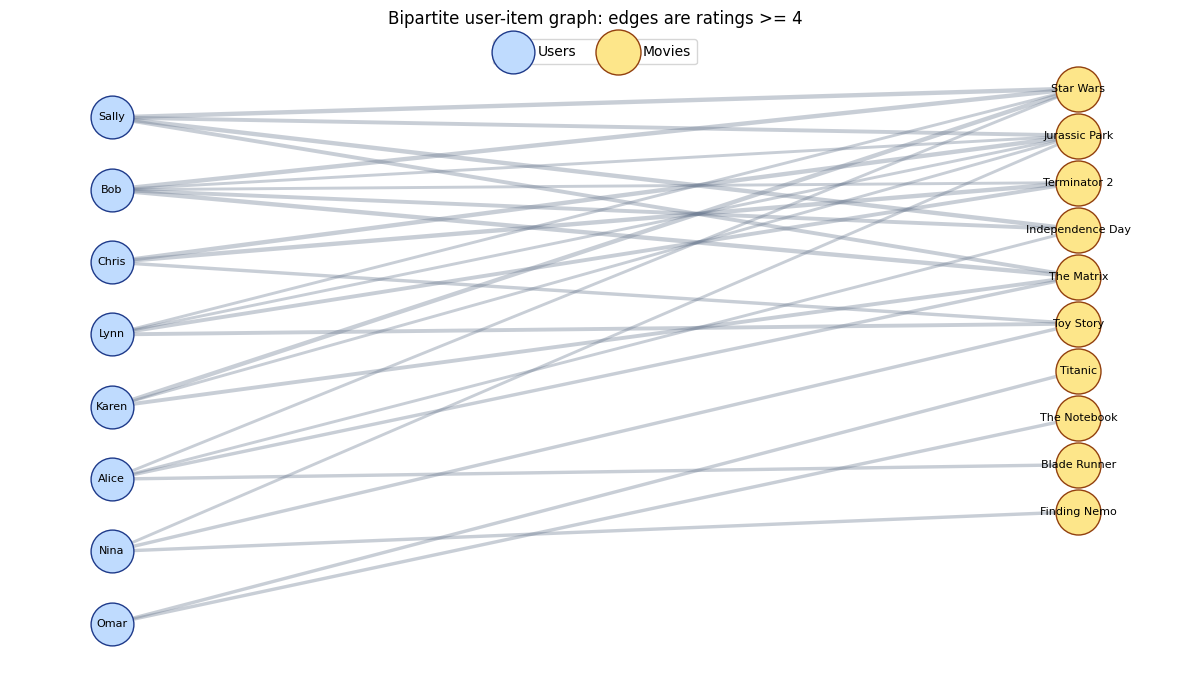

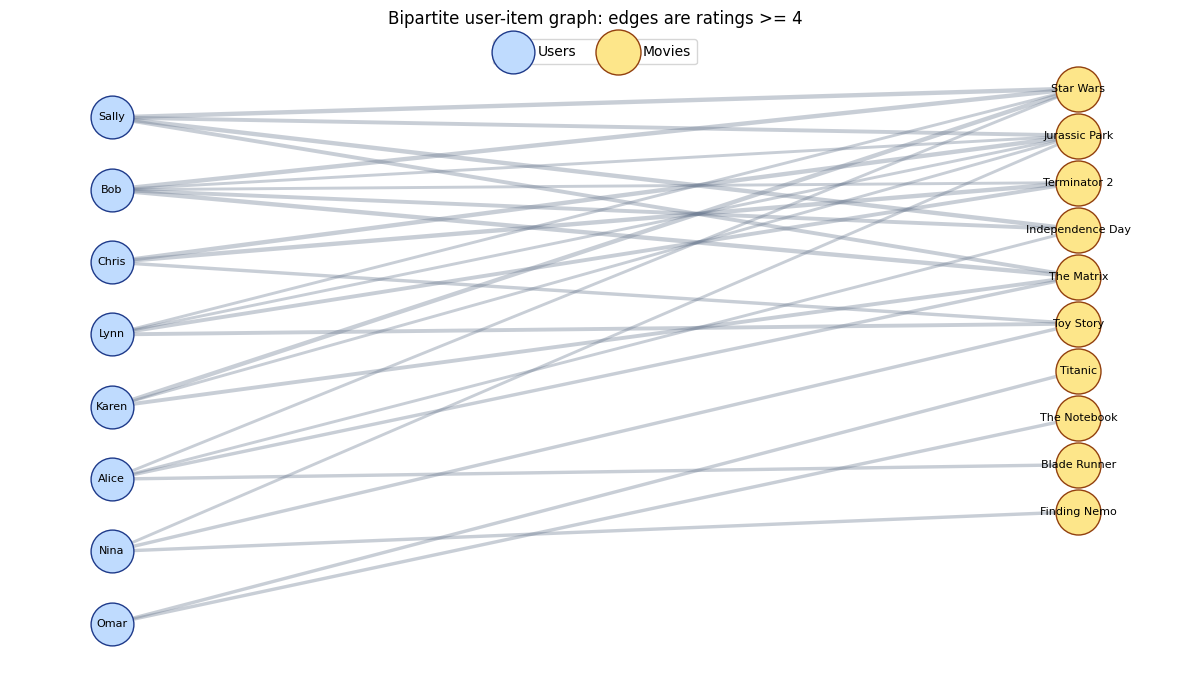

In [2]:
# Teaching note: Build and visualize a bipartite graph with user nodes, item nodes, and rating edges.
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
for user in ratings_named["user_id"].unique():
    G.add_node(f"user:{user}", kind="user", label=user)
for _, row in movies.iterrows():
    G.add_node(f"item:{row['title']}", kind="item", label=row["title"], genre=row["genre"])
for _, row in ratings_named.iterrows():
    if row["rating"] >= 4:
        G.add_edge(f"user:{row['user_id']}", f"item:{row['title']}", weight=row["rating"])

print(nx.info(G) if hasattr(nx, "info") else f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Bipartite layout separates users from movies, making the collaborative signal visible.
user_nodes = [node for node, data in G.nodes(data=True) if data["kind"] == "user"]
item_nodes = [node for node, data in G.nodes(data=True) if data["kind"] == "item"]
pos = {}
for i, node in enumerate(user_nodes):
    pos[node] = (0, -i)
for i, node in enumerate(item_nodes):
    pos[node] = (2.5, -i * 0.65 + 0.4)

fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx_edges(G, pos, width=[0.7 + G[u][v]["weight"] * 0.35 for u, v in G.edges()], alpha=0.35, edge_color="#64748b", ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color="#bfdbfe", edgecolors="#1e3a8a", node_size=950, label="Users", ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=item_nodes, node_color="#fde68a", edgecolors="#92400e", node_size=1050, label="Movies", ax=ax)
labels = {node: data["label"] for node, data in G.nodes(data=True)}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)
ax.legend(loc="upper center", ncol=2)
ax.set_title("Bipartite user-item graph: edges are ratings >= 4")
ax.axis("off")
fig.tight_layout()
fig


,recommended_movie,ppr_score
0,Independence Day,0.044488
1,Toy Story,0.027657
4,Blade Runner,0.012845
5,Finding Nemo,0.007530
2,Titanic,0.000002
3,The Notebook,0.000002


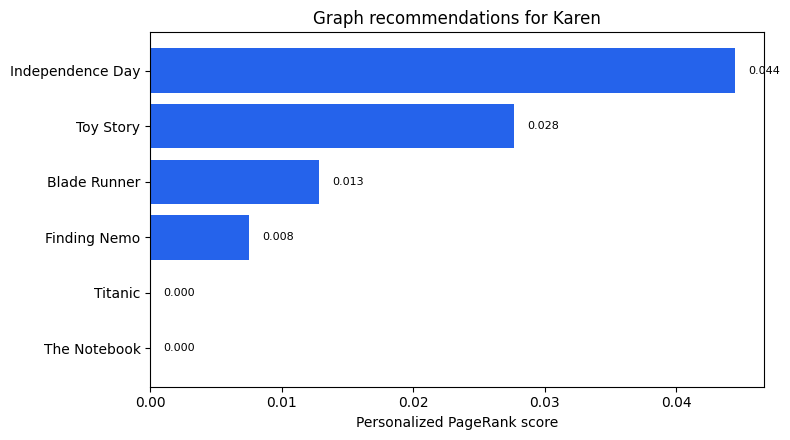

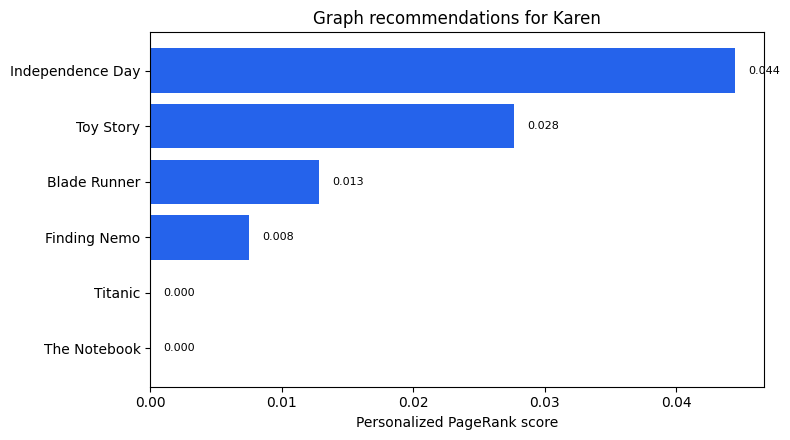

In [3]:
# Teaching note: Run Personalized PageRank from a target user, then visualize the highest-scoring unseen movies.
target_user = "Karen"
seed = {node: 0 for node in G.nodes}
seed[f"user:{target_user}"] = 1

# Personalized PageRank spreads relevance through the interaction graph but repeatedly returns to the target user.
ppr = nx.pagerank(G, alpha=0.85, personalization=seed, weight="weight")
seen = set(rating_matrix.loc[target_user].dropna().index)

recommendations = []
for node, score in ppr.items():
    if node.startswith("item:"):
        title = node.removeprefix("item:")
        if title not in seen:
            recommendations.append({"recommended_movie": title, "ppr_score": score})

ppr_recommendations = pd.DataFrame(recommendations).sort_values("ppr_score", ascending=False).head(6)
display(ppr_recommendations)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(ppr_recommendations["recommended_movie"], ppr_recommendations["ppr_score"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("Personalized PageRank score")
ax.set_title(f"Graph recommendations for {target_user}")
for i, row in ppr_recommendations.reset_index(drop=True).iterrows():
    ax.text(row["ppr_score"] + 0.001, i, f"{row['ppr_score']:.3f}", va="center", fontsize=8)
fig.tight_layout()
fig


,explanation_path
0,Karen -> Star Wars -> Sally -> Independence Day
1,Karen -> Star Wars -> Bob -> Independence Day
2,Karen -> Star Wars -> Alice -> Independence Day


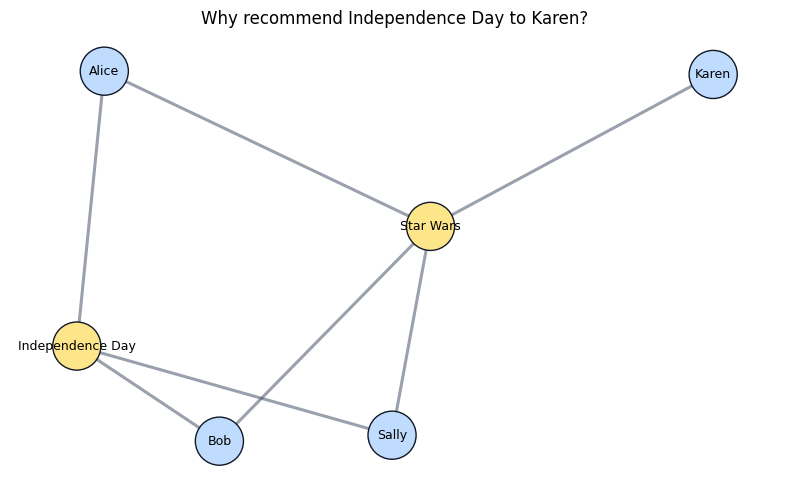

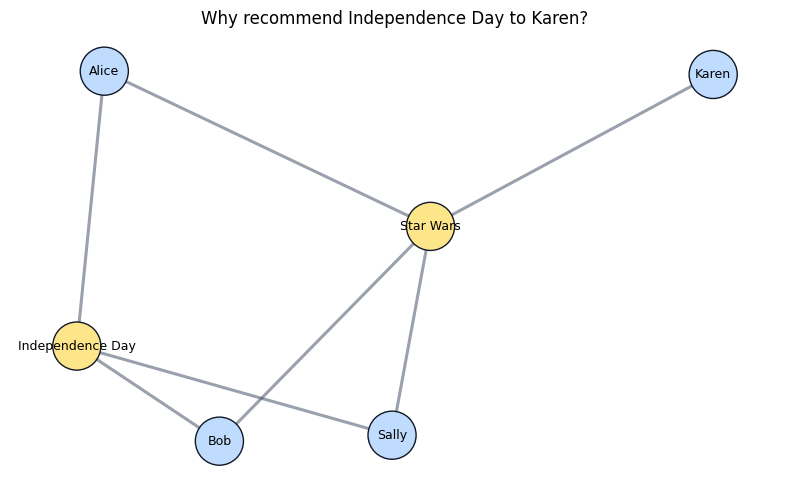

In [4]:
# Teaching note: Explain recommendations with graph paths and draw the local explanation subgraph.
# Graph paths provide a human-readable explanation for PPR recommendations.
def explain_graph_recommendation(graph, user, item, max_paths=3):
    source = f"user:{user}"
    target = f"item:{item}"
    paths = []
    for path in nx.all_simple_paths(graph, source, target, cutoff=4):
        paths.append(path)
        if len(paths) >= max_paths:
            break
    return paths

top_item = ppr_recommendations.iloc[0]["recommended_movie"]
paths = explain_graph_recommendation(G, target_user, top_item)
readable_paths = [" -> ".join(node.replace("user:", "").replace("item:", "") for node in path) for path in paths]
display(pd.DataFrame({"explanation_path": readable_paths}))

# Draw only the nodes and edges used in the explanation paths so the reason is not hidden in the full graph.
path_nodes = sorted({node for path in paths for node in path})
explanation_graph = G.subgraph(path_nodes).copy()
path_pos = nx.spring_layout(explanation_graph, seed=13)
node_colors = ["#bfdbfe" if explanation_graph.nodes[node]["kind"] == "user" else "#fde68a" for node in explanation_graph.nodes]

fig, ax = plt.subplots(figsize=(8, 5))
nx.draw_networkx_edges(explanation_graph, path_pos, width=2.2, alpha=0.55, edge_color="#475569", ax=ax)
nx.draw_networkx_nodes(explanation_graph, path_pos, node_color=node_colors, edgecolors="#111827", node_size=1200, ax=ax)
nx.draw_networkx_labels(explanation_graph, path_pos, labels={node: explanation_graph.nodes[node]["label"] for node in explanation_graph.nodes}, font_size=9, ax=ax)
ax.set_title(f"Why recommend {top_item} to {target_user}?")
ax.axis("off")
fig.tight_layout()
fig


,scenario,movie,score,source
0,known user: graph CF,Independence Day,0.044488,graph_cf
1,known user: graph CF,Toy Story,0.027657,graph_cf
2,known user: graph CF,Blade Runner,0.012845,graph_cf
3,known user: graph CF,Finding Nemo,0.007530,graph_cf
4,known user: graph CF,Titanic,0.000002,graph_cf
5,new user: popularity fallback,Star Wars,10.378187,popular_fallback
6,new user: popularity fallback,The Matrix,9.656627,popular_fallback
7,new user: popularity fallback,Jurassic Park,9.506018,popular_fallback
8,new user: popularity fallback,Terminator 2,8.242094,popular_fallback
9,new user: popularity fallback,Independence Day,7.525390,popular_fallback


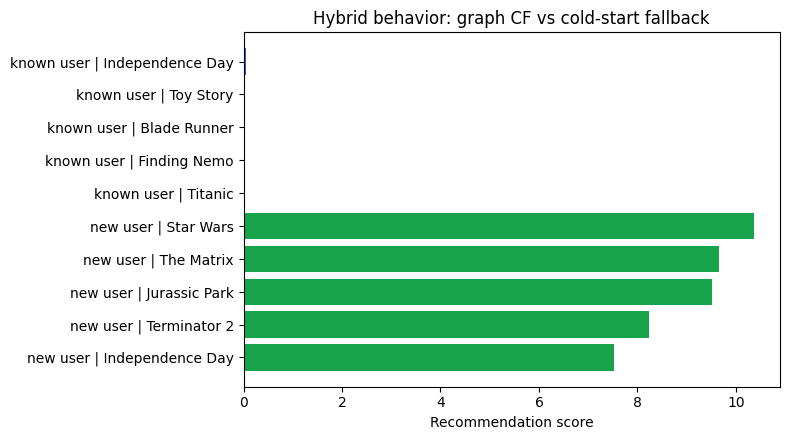

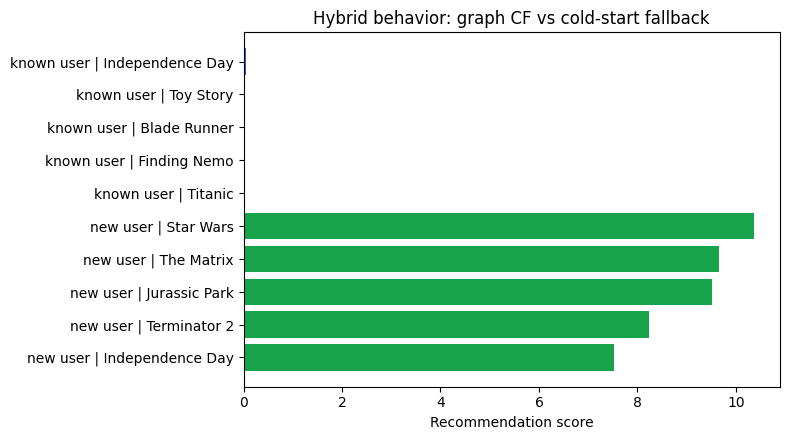

In [5]:
# Teaching note: Compare graph CF for known users with a popularity fallback for cold-start users.
# Hybrid fallback chooses CF when history exists and popularity when it does not.
def hybrid_recommend(user, n=5):
    if user in rating_matrix.index and rating_matrix.loc[user].notna().sum() >= 2:
        seed = {node: 0 for node in G.nodes}
        seed[f"user:{user}"] = 1
        # Personalized PageRank spreads relevance through the interaction graph.
        scores = nx.pagerank(G, alpha=0.85, personalization=seed, weight="weight")
        seen = set(rating_matrix.loc[user].dropna().index)
        rows = []
        for node, score in scores.items():
            if node.startswith("item:"):
                title = node.removeprefix("item:")
                if title not in seen:
                    rows.append({"movie": title, "score": score, "source": "graph_cf"})
        return pd.DataFrame(rows).sort_values("score", ascending=False).head(n)

    # Groupby aggregates ratings by user or item for summary statistics.
    popular = ratings_named.groupby("title")["rating"].agg(["count", "mean"])
    popular["score"] = popular["mean"] * np.log1p(popular["count"])
    return popular.sort_values("score", ascending=False).head(n).reset_index().assign(source="popular_fallback")

known_user_results = hybrid_recommend("Karen")
cold_start_results = hybrid_recommend("NewStudent")
comparison = pd.concat([
    known_user_results.assign(scenario="known user: graph CF"),
    cold_start_results.rename(columns={"title": "movie"}).assign(scenario="new user: popularity fallback"),
], ignore_index=True)
display(comparison[["scenario", "movie", "score", "source"]])

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = comparison.head(10).copy()
plot_data["label"] = plot_data["scenario"].str.split(":").str[0] + " | " + plot_data["movie"]
ax.barh(plot_data["label"], plot_data["score"], color=["#2563eb" if s == "graph_cf" else "#16a34a" for s in plot_data["source"]])
ax.invert_yaxis()
ax.set_xlabel("Recommendation score")
ax.set_title("Hybrid behavior: graph CF vs cold-start fallback")
fig.tight_layout()
fig


## Challenge Lab

1. Change the PageRank `alpha` value from `0.85` to `0.60`, rerun the graph recommendations for `Karen`, and explain whether the ranking becomes more local or more exploratory.
2. Add genre nodes to the graph, connect each movie to its genre, and inspect one recommendation path. Does the added graph structure make the explanation easier to understand?
